RESTAURANT REVIEWS ANALYSIS

Dataset Columns:
Index(['Restaurant ID', 'Restaurant Name', 'Country Code', 'City', 'Address',
       'Locality', 'Locality Verbose', 'Longitude', 'Latitude', 'Cuisines',
       'Average Cost for two', 'Currency', 'Has Table booking',
       'Has Online delivery', 'Is delivering now', 'Switch to order menu',
       'Price range', 'Aggregate rating', 'Rating color', 'Rating text',
       'Votes'],
      dtype='object')

Average Review Length: 1.34 words

Top Positive Keywords:
     Keyword  Frequency
0       good       3179
1       very       1079
2  excellent        301

Top Negative Keywords:
   Keyword  Frequency
0  average       3737
1     poor        186


C:\Users\bharg\AppData\Local\Temp\ipykernel_10396\4216210121.py:120: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


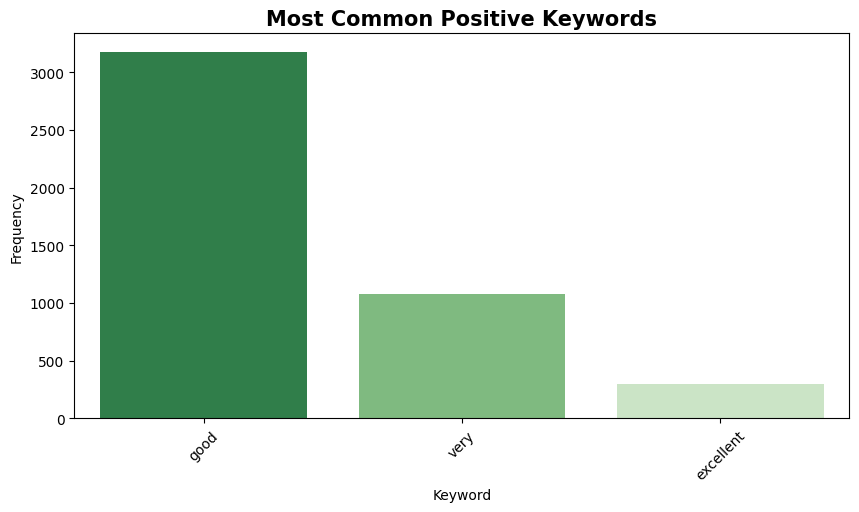

C:\Users\bharg\AppData\Local\Temp\ipykernel_10396\4216210121.py:144: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


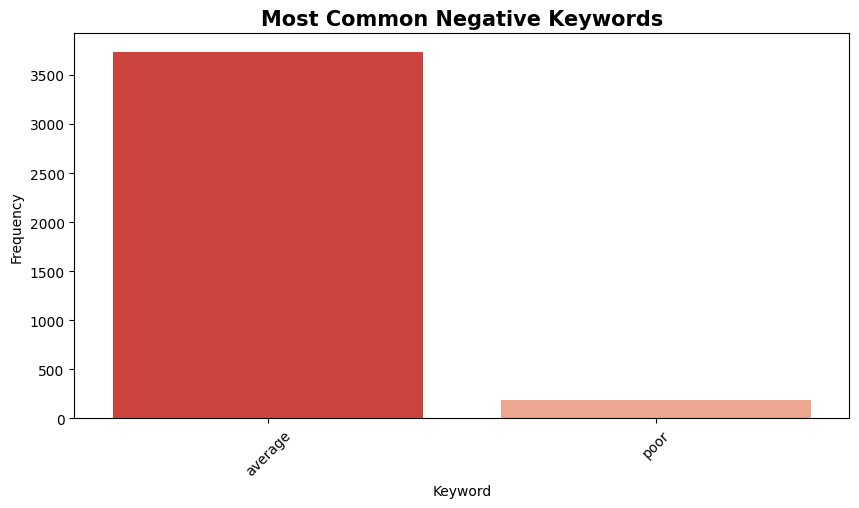

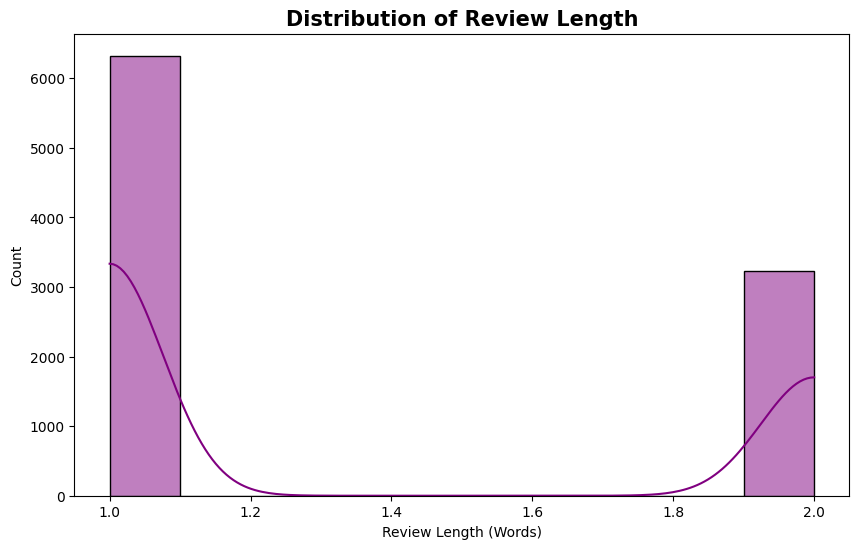

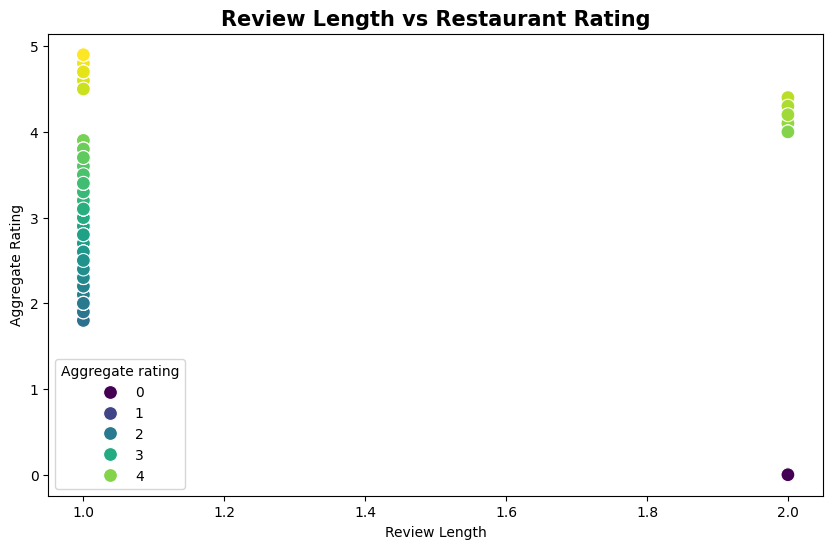


Correlation between Review Length and Rating:
-0.6

CONCLUSION

1. Average Review Length: 1.34 words

2. Most common positive keywords:
good, very, excellent

3. Most common negative keywords:
average, poor

4. Correlation between review length and rating: -0.600

5. Longer reviews tend to be associated with lower ratings.

6. Positive review words occur more frequently than negative review words.


In [1]:
# ==========================================================
# Cognifyz Data Analysis Internship
# Level 3 - Task 1: Restaurant Reviews Analysis
# ==========================================================

# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import re

# ----------------------------------------------------------
# Load Dataset
# ----------------------------------------------------------

df = pd.read_csv(r"D:\2 Year iv sem\Python\Cognifyz-Data-Analysis\Dataset .csv")

print("="*60)
print("RESTAURANT REVIEWS ANALYSIS")
print("="*60)

# ----------------------------------------------------------
# Check Available Columns
# ----------------------------------------------------------

print("\nDataset Columns:")
print(df.columns)

# ----------------------------------------------------------
# Use Rating Text Column
# ----------------------------------------------------------

review_column = "Rating text"

df = df.dropna(subset=[review_column])

# ----------------------------------------------------------
# Convert to Lowercase
# ----------------------------------------------------------

reviews = df[review_column].astype(str).str.lower()

# ----------------------------------------------------------
# Calculate Review Length
# ----------------------------------------------------------

df["Review Length"] = reviews.apply(lambda x: len(x.split()))

avg_review_length = df["Review Length"].mean()

print("\nAverage Review Length:",
      round(avg_review_length,2),"words")

# ----------------------------------------------------------
# Positive & Negative Keywords
# ----------------------------------------------------------

positive_reviews = reviews[
    reviews.isin([
        "excellent",
        "very good",
        "good"
    ])
]

negative_reviews = reviews[
    reviews.isin([
        "poor",
        "average"
    ])
]

# Extract Words
positive_words = " ".join(positive_reviews)
negative_words = " ".join(negative_reviews)

positive_keywords = Counter(
    re.findall(r'\b\w+\b', positive_words)
)

negative_keywords = Counter(
    re.findall(r'\b\w+\b', negative_words)
)

top_positive = positive_keywords.most_common(10)
top_negative = negative_keywords.most_common(10)

# ----------------------------------------------------------
# Positive Keywords Table
# ----------------------------------------------------------

positive_df = pd.DataFrame(
    top_positive,
    columns=["Keyword","Frequency"]
)

print("\nTop Positive Keywords:")
print(positive_df)

# ----------------------------------------------------------
# Negative Keywords Table
# ----------------------------------------------------------

negative_df = pd.DataFrame(
    top_negative,
    columns=["Keyword","Frequency"]
)

print("\nTop Negative Keywords:")
print(negative_df)

# ==========================================================
# Visualization 1
# Positive Keywords
# ==========================================================

plt.figure(figsize=(10,5))

sns.barplot(
    data=positive_df,
    x="Keyword",
    y="Frequency",
    palette="Greens_r"
)

plt.title(
    "Most Common Positive Keywords",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(rotation=45)

plt.show()

# ==========================================================
# Visualization 2
# Negative Keywords
# ==========================================================

plt.figure(figsize=(10,5))

sns.barplot(
    data=negative_df,
    x="Keyword",
    y="Frequency",
    palette="Reds_r"
)

plt.title(
    "Most Common Negative Keywords",
    fontsize=15,
    fontweight="bold"
)

plt.xticks(rotation=45)

plt.show()

# ==========================================================
# Review Length Distribution
# ==========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df["Review Length"],
    bins=10,
    kde=True,
    color="purple"
)

plt.title(
    "Distribution of Review Length",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Review Length (Words)")
plt.ylabel("Count")

plt.show()

# ==========================================================
# Relationship Between Review Length & Rating
# ==========================================================

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Review Length",
    y="Aggregate rating",
    hue="Aggregate rating",
    palette="viridis",
    s=100
)

plt.title(
    "Review Length vs Restaurant Rating",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Review Length")
plt.ylabel("Aggregate Rating")

plt.show()

# ----------------------------------------------------------
# Correlation
# ----------------------------------------------------------

correlation = df["Review Length"].corr(
    df["Aggregate rating"]
)

print("\nCorrelation between Review Length and Rating:")
print(round(correlation,3))

# ==========================================================
# Conclusion
# ==========================================================

print("\n" + "="*60)
print("CONCLUSION")
print("="*60)

print(f"\n1. Average Review Length: {avg_review_length:.2f} words")

print("\n2. Most common positive keywords:")
print(", ".join(positive_df["Keyword"].head(5)))

print("\n3. Most common negative keywords:")
print(", ".join(negative_df["Keyword"].head(5)))

print(f"\n4. Correlation between review length and rating: {correlation:.3f}")

if correlation > 0:
    print("\n5. Longer reviews tend to be associated with higher ratings.")
elif correlation < 0:
    print("\n5. Longer reviews tend to be associated with lower ratings.")
else:
    print("\n5. No significant relationship found between review length and ratings.")

print("\n6. Positive review words occur more frequently than negative review words.")